# **Trabajo Práctico N° 1**

### **Actividad 1:**

Para resolver esta actividad se abrió y exploró el archivo .cvs que contenia todos los registros con los cuales se debia trabajar durante el trabajo, se encontro lo siguiente:

- Cada fila representa: una paciente individual (mujeres de al menos 21 años pertenecientes a la población Pima Indian).  
- Cada columna representa: una variable clínica específica que fue medida en la paciente (edad, nivel de insulina, presión arterial, etc.), a excepción de la última columna (outcome) que contiene el diagnóstico final (1 = Tiene diabetes, 0 = no tiene diabetes).  
- Número de instancias: observando la primera columna (la cual no tiene etiqueta) notamos que de trataba de un ID, que iba de 0 a 767, por lo que hay 768 instancias.
- Número total de columnas: hay 9 columnas principales con información médica y de diagnóstico (existe una decima columna que se nombro en el punto anterior, que seria un ID de cada entrada).
- Número de atributos predictores: hay 8 atributos predictores en total, las mediciones clínicas (número de embarazos, nivel de glucosa en sangre, presión arterial, grosor del pliegue cutáneo, nivel de insulina, índice de masa corporal, función genética asociada a diabetes y edad).  
- Variable objetivo: es la columna llamada Outcome, nos indica el diagnóstico final.  

#### Tipo de problema de aprendizaje automático:
Este dataset representa un problema de clasificación, ya que el objetivo del modelo será predecir a qué categoría discreta pertenece una paciente nueva (tiene o no tiene diabetes) con la variable Outcome.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df_diabetes = pd.read_csv("./data/diabetes.csv")
df_diabetes.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [5]:
df_diabetes.tail()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,763,10,101,76.0,48.0,180.0,32.9,0.171,63,0
764,764,2,122,70.0,27.0,0.0,36.8,0.340,27,0
765,765,5,121,72.0,23.0,112.0,26.2,0.245,30,0
766,766,1,126,60.0,0.0,0.0,30.1,0.349,47,1
767,767,1,93,70.0,31.0,0.0,30.4,0.315,23,0


### **Actividad 2:**

Se utilizaron funciones pertenecientes a la biblioteca de pandas (info(), describe() y hist()) exploramos mas en detalle los datos del archivo:

In [6]:
df_diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             767 non-null    float64
 4   SkinThickness             756 non-null    float64
 5   Insulin                   763 non-null    float64
 6   BMI                       767 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
 9   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 60.1 KB


In [7]:
df_diabetes.describe()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,767.000000,756.000000,763.000000,767.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.195567,20.862434,80.322412,32.034289,0.471876,33.240885,0.348958
std,221.846794,3.369578,31.972618,19.206609,15.865314,115.439459,7.804050,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,191.750000,1.000000,99.000000,63.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,36.000000,32.000000,0.372500,29.000000,0.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,128.500000,36.600000,0.626250,41.000000,1.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**¿Qué tipos de datos aparecen?**

Al ejecutar la función df_diabetes.info(), se observa que todos los atributos del dataset son numéricos. Hay 5 columnas de tipo entero (int64) y 5 columnas de tipo flotante o decimal (float64).  

**¿Existen valores faltantes?**

Sí. La misma función info(), asi como la función describe(), revela que aunque hay 768 pacientes (instancias) columnas como BloodPressure (767), SkinThickness (756), Insulin (763) y BMI (767) tienen menos datos no nulos, lo que indica que hay valores faltantes (además existen ceros que también actúan como datos faltantes encubiertos, se analizará mas adelante).  

**¿Existen variables con escalas muy diferentes?**

Sí. En el cuadro estadístico generado por df_diabetes.describe() se observa diferencia de escalas entre los atributos. Por ejemplo: la función genética (DiabetesPedigreeFunction) varia en un rango pequeño (0.078 a 2.42), pero otros atributos como el nivel de insulina (Insulin) alcanzan valores extremos de hasta 846. Esta diferencia hará que sea necesario aplicar un proceso de estandarización antes de entrenar un modelo, para evitar que las variables con números más altos dominen los cálculos.

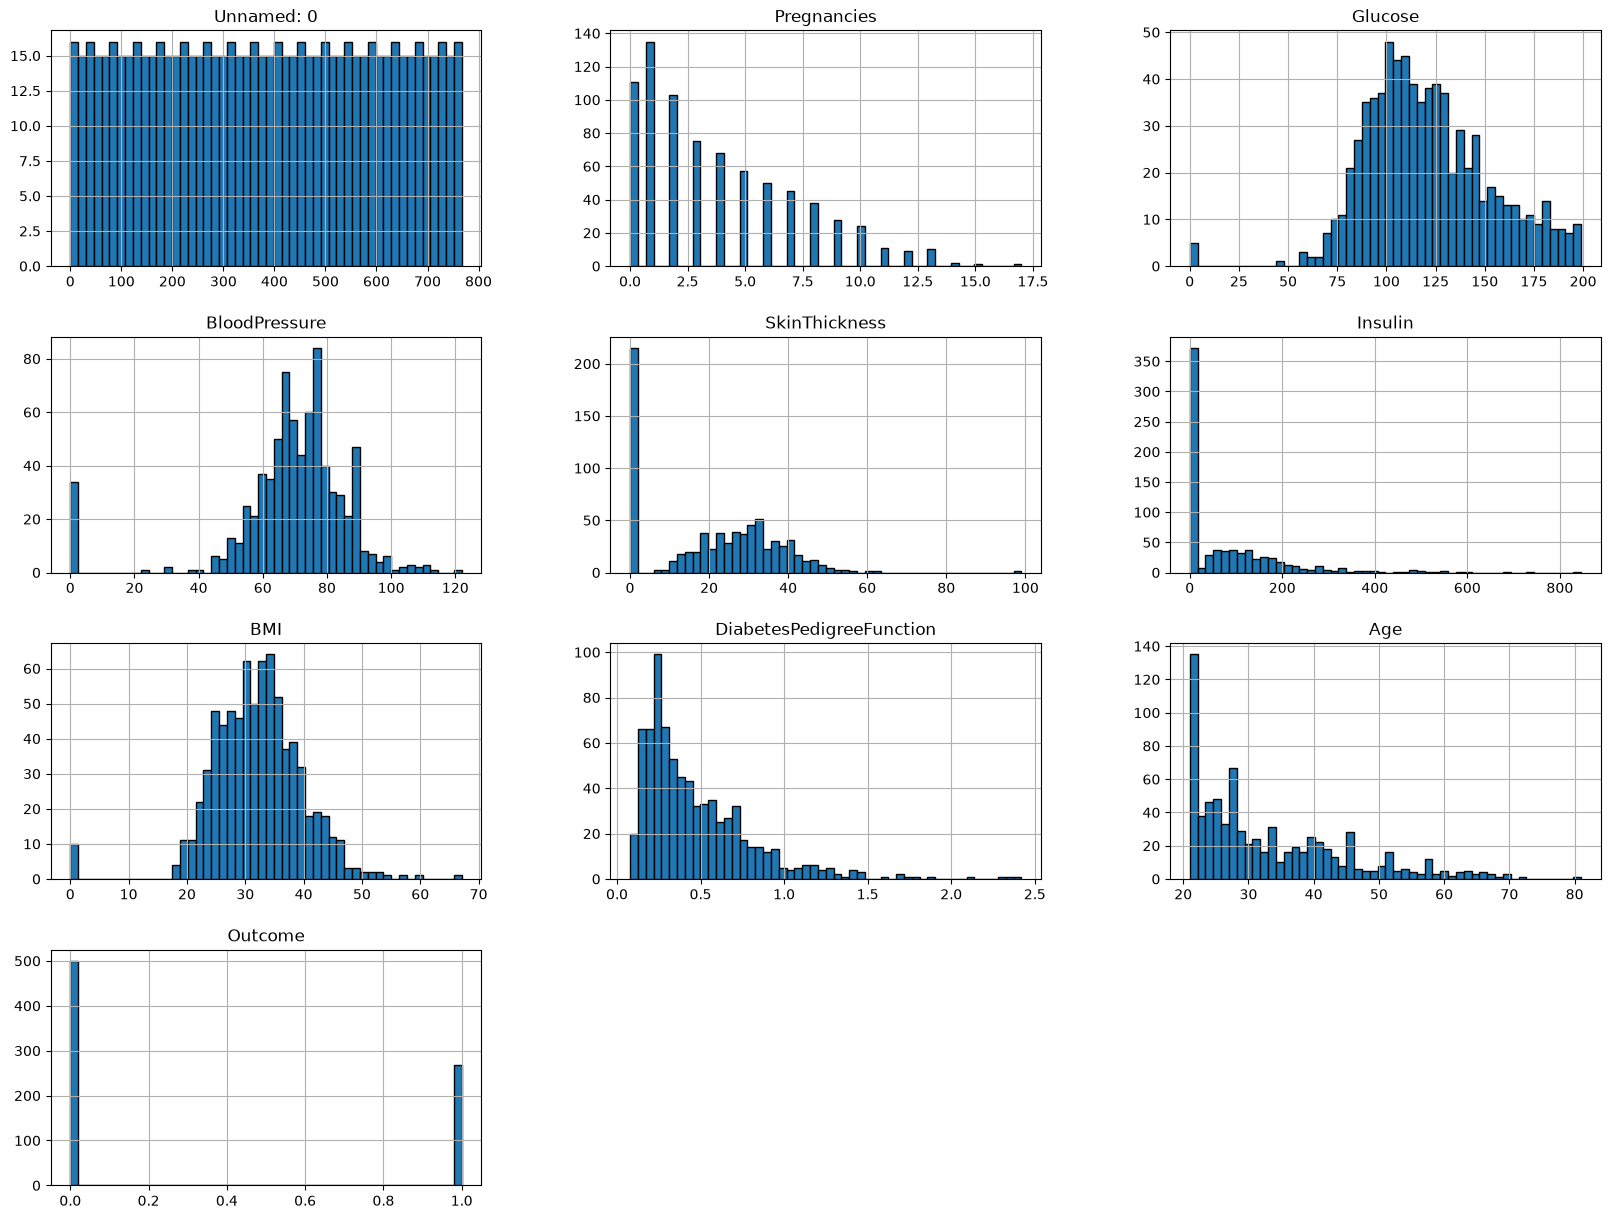

In [8]:
df_diabetes.hist(bins=50, edgecolor='k', figsize=(20,15))
plt.show()

**¿Existen variables con distribuciones sesgadas?**

Al graficar los histogramas del conjunto de datos, se observa que variables como Age, Pregnancies, DiabetesPedigreeFunction e Insulin presentan una fuerte distribución sesgada hacia la izquierda. Esto significa que sus valores se extienden mucho más hacia los números bajos, perdiendo la forma de campana simétrica (distribución normal). Esto podría requerir aplicar transformaciones matemáticas (como logaritmos) antes del modelado para mejorar la detección de patrones.

### **Actividad 3:**

#### División del dataset en conjunto de entrenamiento y de prueba

Para separar los datos se optó por aplicar la técnica de muestreo estratificado utilizando la variable objetivo Outcome como criterio de división.
En los problemas de aprendizaje automático, es crucial que los conjuntos de entrenamiento (train) y prueba (test) sean representativos de la distribución original de los datos. A partir de los histogramas realizados en el punto anterior es posible ver que la variable Outcome presenta mayor cantidad de valores 0, ósea que hay mas cantidad de pacientes sin diabetes que con diabetes, además se observa en el cuadro de estadísticos (realizado con describe()) que la media de Outcome es de aprox. 0.35, y siendo que los valores posibles son 1 y 0, se puede concluir que aproximadamente el 35% de los pacientes analizados tienen diabetes. Por lo que, si se quiere respetar la proporción de la población original, realizar una división aleatoria simple presenta un riesgo: el conjunto de prueba podría terminar con una proporción irreal de pacientes, lo cual haría que las evaluaciones del modelo sean engañosas.  Al estratificar mediante la variable Outcome (parámetro stratify=df_diabetes["Outcome"]), obligamos al algoritmo de división a mantener exactamente la misma proporción original de mujeres con diabetes y sin diabetes en ambos subconjuntos, ya que el algoritmo se ocupa de escanear los datos antes de hacer los cortes y fuerza a que ambas partes mantengan las proporciones originales. Se asignó el 20% de los datos al conjunto de prueba, el cual se reserva de manera aislada para la evaluación final y no se utiliza durante la fase de análisis y preparación.

In [9]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_diabetes, test_size=0.2, stratify=df_diabetes["Outcome"], random_state=42)

In [10]:
diabetes = train_set.copy()

### **Actividad 4:**

Atributos como Glucose, BloodPressure, SkinThickness, Insulin y BMI presentan valores mínimos de 0. En condiciones clínicas reales esto es biológicamente imposible, por lo que deben considerarse como datos faltantes o errores de medición, estos valores no representan mediciones genuinas, sino instancias donde el personal médico no registró esa información. (Aclaración: El 0 en Pregnancies sí es válido, ya que solo marca que la persona nunca estuvo embarazada).

**Estrategia para tratarlos:**

Consiste en reemplazar primero todos estos ceros por valores nulos (NaN en numpy) dentro del conjunto de entrenamiento. De esta forma, evitamos que los algoritmos procesen matemáticamente estos ceros como si fueran medidas reales, lo cual sesgaría severamente los cálculos. Posteriormente se aplicará un proceso de imputación:

**Imputación por clase:** se considera aplicar este tipo de imputación donde se tomaran los valores de mediana de cada clase creada, donde estas clases serán definidas según los valores de Outcome, ósea, una clase con personas con diabetes y una clase con personas sin diabetes. Aplicar esta estrategia es estadísticamente factible solo para el conjunto de datos que se tiene actualmente, mas no lo será cuando se intente ingresar un paciente nuevo al sistema. Esto se debe a que cuando se ingresa una nueva paciente el valor de Outcome es una incógnita que se quiere resolver (utilizando los valores predictivos), por lo tanto seria imposible clasificar a la paciente en alguna clase en caso de tener datos faltantes, el sistema no podría saber como completarlos. 

**Fuga de información:** si usamos Outcome para calcular la imputación estaríamos filtrando la respuesta correcta hacia las variables predictoras. El modelo, en ves de aprender la relación entre los valores de los predictores y el diagnostico, va a tomar un atajo creado por una pista artificial (el ya tener el diagnostico en las instancias actuales) y en consecuencia mostrara métricas de éxito sumamente altas que serán falsas.

**Estrategia adoptada finalmente:** 

Para garantizar la consistencia entre el entrenamiento y la predicción, aplicaremos una imputación global utilizando la mediana general del conjunto de entrenamiento. Esto se hace omitiendo el Outcome durante el cálculo. Se utilizará la mediana en ves de la media dado que la mayoría de los parámetros predictores muestran ser sesgados, por lo tanto la mediana será un descriptor mas apropiado.


In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np
diabetes_train_X = train_set.drop("Outcome", axis=1)
columnas_con_cero= ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_global= diabetes_train_X.copy()
df_global[columnas_con_cero]=df_global[columnas_con_cero].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")
df_global[columnas_con_cero] = imputer.fit_transform(diabetes_train_X[columnas_con_cero])

train_set[columnas_con_cero] = train_set[columnas_con_cero].replace(0, np.nan)
medianas_globales = train_set[columnas_con_cero].median()
print(medianas_globales)

Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.4
dtype: float64


### **Análisis exploratorio: imputación condicional**

Realizamos una imputación condicionada por la variable Outcome (calculando una mediana para pacientes con diabetes y otra para pacientes sin diabetes) y la comparamos con la imputación global realizada anteriormente. Notamos que las medianas condicionadas reflejan de forma más precisa los valores de cada grupo. Pero esta versión no puede usarse de forma definitiva, por las razones explicadas con anterioridad.

In [15]:
df_condicional = diabetes_train_X.copy()
df_condicional[columnas_con_cero] = df_condicional[columnas_con_cero].replace(0, np.nan)

# Volvemos a pegar Outcome temporalmente para poder agrupar
df_condicional["Outcome"] = train_set["Outcome"]

for col in columnas_con_cero:
    medianas_por_clase = df_condicional.groupby("Outcome")[col].median()
    df_condicional[col] = df_condicional.apply(
        lambda row: medianas_por_clase[row["Outcome"]] if pd.isna(row[col]) else row[col],
        axis=1
    )

# Mostrar las medianas por clase directamente
train_set.groupby("Outcome")[columnas_con_cero].apply(lambda g: g.replace(0, np.nan).median())

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
Outcome,,,,,
0,108.0,70.0,27.0,100.0,30.10
1,141.5,76.0,33.0,168.0,34.35


Al comparar ambas estrategias es evidente que la imputación condicionada es mucho más precisa y realista. Esto se debe a que las pacientes con diabetes presentan valores de parametros clínicos más altos (una mediana de glucosa de 141.5 frente a 108.0 en pacientes sanas).

Al utilizar la imputación global (Glucosa 117.0) estamos introduciendo un pequeño margen de error: subestimamos los valores reales de las pacientes diabéticas y sobreestimamos los de las sanas (a pesar de que las medianas globales presentan valores ligeramente mas pareciados a las medianas de personas sanas; se estima que esto se debe a que hay mas cantidad de pacientes sanos que con diabetes). 

En consecuencia, la imputación condicionada se utiliza únicamente con fines exploratorios (para dimensionar el margen de error introducido) mientras que la imputación global, ajustada exclusivamente sobre el conjunto de entrenamiento, es la que se aplica de forma consistente al pipeline final.

### **Actividad 5:**

Para responder lo preguntado en este punto se tiene en cuenta un dato ya visto anteriormente en la tabla de estadísticos, como ya se nombro, al ser la media aproximadamente 0.35 para la etiqueta Outcome, se estima que el 35% de los pacientes del archivo tienen diabetes, mientras que el 65% restante no tiene diabetes. Dado que para que una clase sea balanceada la distribución de los datos debería ser prácticamente 50/50, teniendo en cuanta lo ya dicho, se puede concluir que la clase es desbalanceada. 

In [30]:
print("Cantidad de casos con diabetes (1) y sin diabetes (0):")
print(df_diabetes["Outcome"].value_counts())
# Para verlo en porcentaje
print("Porcentajes:")
print(df_diabetes["Outcome"].value_counts(normalize=True))

Cantidad de casos con diabetes (1) y sin diabetes (0):
Outcome
0    500
1    268
Name: count, dtype: int64
Porcentajes:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


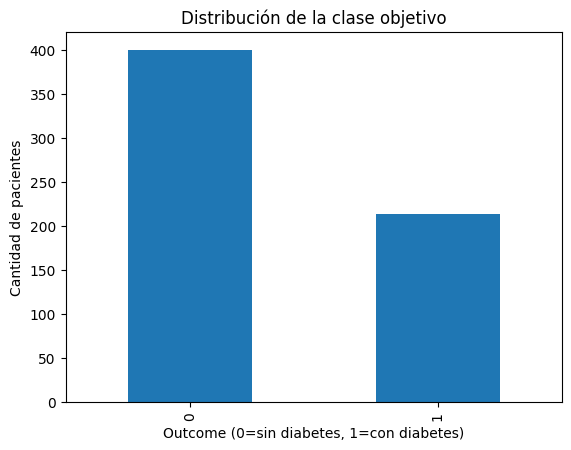

In [31]:
import matplotlib.pyplot as plt
train_set["Outcome"].value_counts().plot(kind="bar")
plt.xlabel("Outcome (0=sin diabetes, 1=con diabetes)")
plt.ylabel("Cantidad de pacientes")
plt.title("Distribución de la clase objetivo")
plt.show()

#### **Preparación Completa**

Para que los datos sean útiles para un modelo de aprendizaje es necesario escalar los atributos numéricos ya que manejan rangos muy diferentes. Se optó por aplicar una estandarización (StandardScaler) en lugar de una normalización. Esto porque la estandarización es menos sensible a la presencia de valores atípicos extremos. Por ejemplo, en el cuadro estadístico se ve que el atributo Insulin tiene el 75% de sus mediciones por debajo de 128.5, pero presenta un valor máximo de 846. La estandarización es el enfoque adecuado para manejar este tipo de saltos en la distribución.

Se procede primero con los pasos ya explicados en actividades anteriores, agregando los procesos descritos en el parrafo anterior:

#### **Split**

En está parte también se agrega un cambio con respecto a lo anterior, dado que la biblioteca que se utilizara para el entrenamiento requiere un formato específico. Este formato consiste en la división de los datos en dos grupos, dado que se utilizará la función modelo.fit(X, Y):

- X: las clases predictoras, osea lo que usamos para predecir.
- Y: lo que se predice (en este caso Outcome)

Esto se hace porque si se deja Outcome dentro de las variables predictoras, le estaríamos dando al modelo la respuesta correcta como pista, provocando la fuga de información de la que se habló anteriormente. 

In [32]:
X_train= train_set.drop("Outcome", axis=1)
Y_train = train_set["Outcome"]

X_test= test_set.drop("Outcome", axis=1)
Y_test = test_set["Outcome"]

#### **Columnas con ceros**

In [ ]:
from sklearn.impute import SimpleImputer

columnas_con_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

X_train[columnas_con_cero] = X_train[columnas_con_cero].replace(0, np.nan)
X_test[columnas_con_cero] = X_test[columnas_con_cero].replace(0, np.nan)

#### **Imputacion**

In [34]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train[columnas_con_cero] = imputer.fit_transform(X_train[columnas_con_cero])
X_test[columnas_con_cero] = imputer.transform(X_test[columnas_con_cero])

Antes de estandarizar, aplicamos una **transformación logarítmica** a Insulin para reducir su fuerte sesgo y hacer la distribución más simétrica.

In [35]:
X_train["Insulin"] = np.log(X_train["Insulin"])
X_test["Insulin"] = np.log(X_test["Insulin"])

#### **Estandarización**

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### **Verificacion**

In [37]:
print(X_train_scaled.shape, X_test_scaled.shape)
print(pd.DataFrame(X_train_scaled, columns= X_train.columns).describe())

(614, 9) (154, 9)
         Unnamed: 0   Pregnancies       Glucose  BloodPressure  SkinThickness  \
count  6.140000e+02  6.140000e+02  6.140000e+02   6.140000e+02   6.140000e+02   
mean   9.402540e-17 -6.943414e-17 -1.099374e-16   3.095606e-16  -3.471707e-17   
std    1.000815e+00  1.000815e+00  1.000815e+00   1.000815e+00   1.000815e+00   
min   -1.719458e+00 -1.153338e+00 -2.190541e+00  -3.924957e+00  -2.480958e+00   
25%   -8.688162e-01 -8.513551e-01 -7.562208e-01  -6.636760e-01  -4.549828e-01   
50%   -2.490813e-02 -2.473897e-01 -1.558076e-01  -1.141979e-02  -4.766137e-03   
75%    8.829664e-01  6.585583e-01  6.113872e-01   6.408364e-01   3.328964e-01   
max    1.719019e+00  3.980368e+00  2.579408e+00   4.065181e+00   7.874025e+00   

            Insulin           BMI  DiabetesPedigreeFunction           Age  
count  6.140000e+02  6.140000e+02              6.140000e+02  6.140000e+02  
mean  -4.267307e-16  1.649061e-16             -1.099374e-16 -1.084908e-16  
std    1.000815e+00  1.0